In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_df = pd.read_csv('fear_greed_index.csv')
trader_df = pd.read_csv('historical_data.csv')

print("Files successfully loaded!")
print(f"Sentiment records: {len(sentiment_df)}")
print(f"Trader records: {len(trader_df)}")

Files successfully loaded!
Sentiment records: 2644
Trader records: 211224


In [21]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

trader_df['Timestamp IST'] = pd.to_datetime(trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M')
trader_df['date'] = trader_df['Timestamp IST'].dt.normalize()

merged_df = pd.merge(trader_df, sentiment_df, on='date', how='inner')

print("Data cleaning and merging complete.")
merged_df[['date', 'classification', 'Closed PnL', 'Side']].head()

Data cleaning and merging complete.


,date,classification,Closed PnL,Side
0,2024-12-02,Extreme Greed,0.0,BUY
1,2024-12-02,Extreme Greed,0.0,BUY
2,2024-12-02,Extreme Greed,0.0,BUY
3,2024-12-02,Extreme Greed,0.0,BUY
4,2024-12-02,Extreme Greed,0.0,BUY


In [22]:
pnl_stats = merged_df.groupby('classification')['Closed PnL'].agg(['mean', 'count']).reset_index()

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
pnl_stats['classification'] = pd.Categorical(pnl_stats['classification'], categories=sentiment_order, ordered=True)
pnl_stats = pnl_stats.sort_values('classification')

print("Sentiment-wise Trader Performance:")
print(pnl_stats)

Sentiment-wise Trader Performance:
  classification       mean  count
0   Extreme Fear  34.537862  21400
2           Fear  54.290400  61837
4        Neutral  34.307718  37686
3          Greed  42.743559  50303
1  Extreme Greed  67.892861  39992


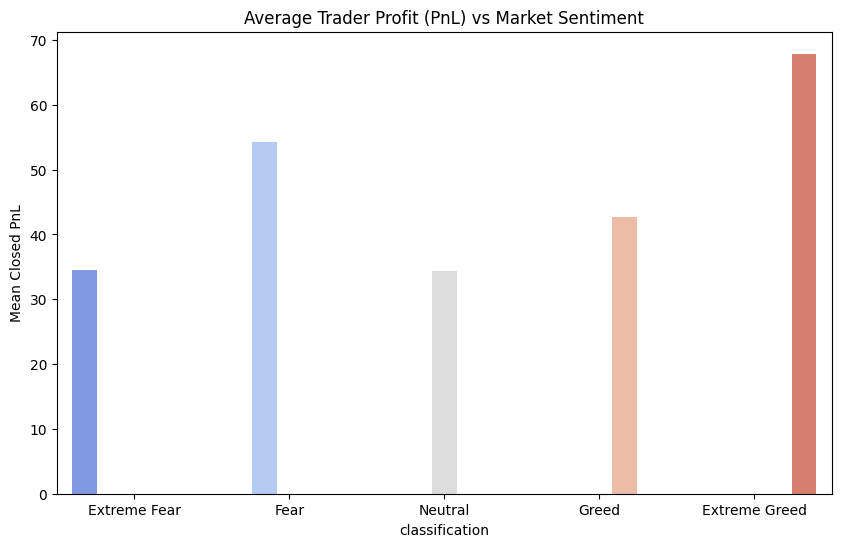

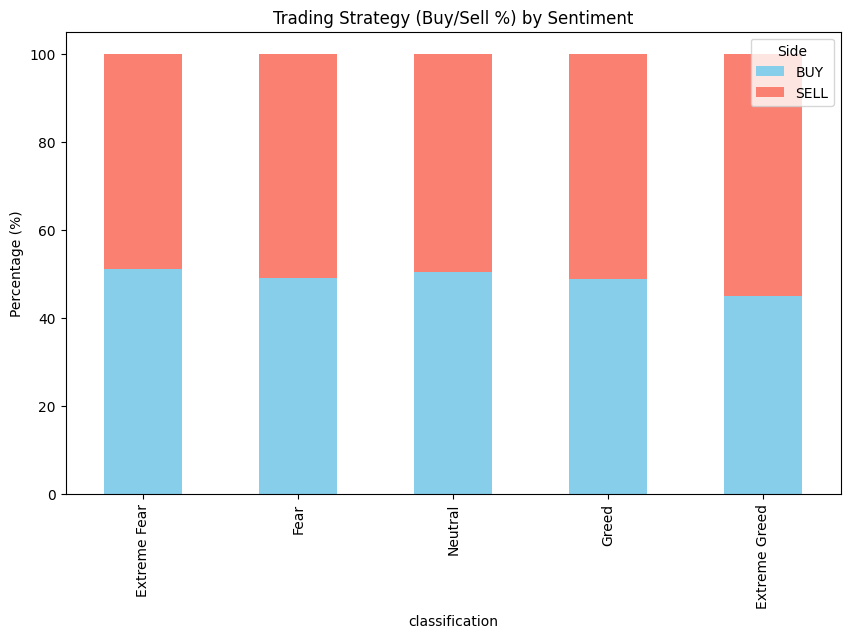

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(data=pnl_stats, x='classification', y='mean', hue='classification', palette='coolwarm', legend=False)
plt.title('Average Trader Profit (PnL) vs Market Sentiment')
plt.ylabel('Mean Closed PnL')
plt.savefig('avg_pnl_sentiment.png')
plt.show()

side_dist = pd.crosstab(merged_df['classification'], merged_df['Side'], normalize='index') * 100
side_dist.loc[sentiment_order].plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Trading Strategy (Buy/Sell %) by Sentiment')
plt.ylabel('Percentage (%)')
plt.legend(title='Side')
plt.savefig('trading_strategy.png')
plt.show()